# **YOLO11 (You Only Look Once)**
**YOLO** (You Only Look Once) is a popular object detection model known for its speed and accuracy. It performs real-time object detection by processing the entire image in a single pass, making it highly efficient for various applications.

<img src = https://learnopencv.com/wp-content/uploads/2025/02/Yolo_Models_Timeline.png >





## **YOLO11**

YOLO11 is a SOTA Object Detection model improving upon its predecessors. Its extra-large model achieves an highest **COCO mAP50:95** of **54.7**.
### **YOLO11 Family of Models:**

| Model   | Size (pixels) | mAPval 50-95 | Speed CPU ONNX (ms) | Speed T4 TensorRT10 (ms) | Params (M) | FLOPs (B) |
|---------|--------------|--------------|----------------------|--------------------------|------------|-----------|
| YOLO11n | 640          | 39.5         | 56.1 ± 0.8           | 1.5 ± 0.0                | 2.6        | 6.5       |
| YOLO11s | 640          | 47.0         | 90.0 ± 1.2           | 2.5 ± 0.0                | 9.4        | 21.5      |
| YOLO11m | 640          | 51.5         | 183.2 ± 2.0          | 4.7 ± 0.1                | 20.1       | 68.0      |
| YOLO11l | 640          | 53.4         | 238.6 ± 1.4          | 6.2 ± 0.1                | 25.3       | 86.9      |
| YOLO11x | 640          | 54.7         | 462.8 ± 6.7          | 11.3 ± 0.2               | 56.9       | 194.9     |

### **YOLO11 vs Other Object Detectors:**

<img src =https://raw.githubusercontent.com/ultralytics/assets/refs/heads/main/yolo/performance-comparison.png>

### **Key Features:**

- **Highly Adaptable**: The YOLO11 family contains models of different sizes that are appropriate for different applications. Small models can be used on the edge, while larger models can run on the servers for better accuracy.

- **Multiple Supported Tasks**: Object detection, instance segmentation, classification, pose estimation, oriented object detection.

### **Resources:**
**Github**: [YOLO11 Repository](https://github.com/ultralytics/ultralytics)

**Blogpost**: [YOLO11 on LearnOpenCV](https://learnopencv.com/yolo11/)

**Ultralytics**: [Ultralytics](https://ultralytics.com) is a platform built upon PyTorch, hosting various models like **YOLOv5**, **YOLOv8**, **YOLOv9**, **YOLOv10**, **YOLO11**, **SAM** and **RW-DETR** and simplifies the process of training, inference and deployment.  In this final tutorial notebook, we will make use of ultralytics library to perform Object Detection task with **YOLO11**.



### Installing Dependencies

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 5.5 MB/s eta 0:00:00


In [32]:
# !wget -q https://learnopencv.com/wp-content/uploads/2024/08/soccer-scaled.jpg -O football.jpg
# !wget -q https://learnopencv.com/wp-content/uploads/2024/08/zebra-yolov10-scaled.jpg -O zebra.jpg
# !wget -q https://learnopencv.com/wp-content/uploads/2024/08/monitor-yolov10-scaled.jpg -O monitor.jpg
# !wget -q https://learnopencv.com/wp-content/uploads/2024/08/kitchen-scaled.jpg -O kitchen.jpg
# !wget -q https://learnopencv.com/wp-content/uploads/2024/08/cat-dog-yolov10-v1.jpeg -O cat-dog.jpg
# !wget -q https://learnopencv.com/wp-content/uploads/2025/02/tiger-scaled.jpg -O tiger.jpg
# !wget -q https://learnopencv.com/wp-content/uploads/2025/02/boat-ob.jpg -O boat.jpg

In [36]:
# !curl -H "User-Agent: Mozilla/5.0" -sL "https://learnopencv.com/wp-content/uploads/2024/08/soccer-scaled.jpg" -o football.jpg
# !curl -H "User-Agent: Mozilla/5.0" -sL "https://learnopencv.com/wp-content/uploads/2024/08/zebra-yolov10-scaled.jpg" -o zebra.jpg
# !curl -H "User-Agent: Mozilla/5.0" -sL "https://learnopencv.com/wp-content/uploads/2024/08/monitor-yolov10-scaled.jpg" -o monitor.jpg
# !curl -H "User-Agent: Mozilla/5.0" -sL "https://learnopencv.com/wp-content/uploads/2024/08/kitchen-scaled.jpg" -o kitchen.jpg
# !curl -H "User-Agent: Mozilla/5.0" -sL "https://learnopencv.com/wp-content/uploads/2024/08/cat-dog-yolov10-v1.jpeg" -o cat-dog.jpg
# !curl -H "User-Agent: Mozilla/5.0" -sL "https://learnopencv.com/wp-content/uploads/2025/02/tiger-scaled.jpg" -o tiger.jpg
# !curl -H "User-Agent: Mozilla/5.0" -sL "https://learnopencv.com/wp-content/uploads/2025/02/boat-ob.jpg" -o boat.jpg


In [48]:
# Clean up the broken HTML files first
# !rm -f football.jpg zebra.jpg monitor.jpg kitchen.jpg cat-dog.jpg tiger.jpg boat.jpg

# Download unblocked alternative sources
# !wget -q -O football.jpg "https://wikimedia.org"
# !wget -q -O zebra.jpg "https://wikimedia.org"
# !wget -q -O monitor.jpg "https://githubusercontent.com"
# !wget -q -O kitchen.jpg "https://wikimedia.org"
# !wget -q -O cat-dog.jpg "https://githubusercontent.com" || wget -q -O cat-dog.jpg "https://wikimedia.org"
# !wget -q -O tiger.jpg "https://wikimedia.org"
# !wget -q -O boat.jpg "https://wikimedia.org"

# print("Done! Check your files sidebar—they are ready for YOLO.")

In [51]:
import base64

def save_base64_image(base64_string, output_filename="football.jpg"):
    try:
        # Strip the data URI header if it exists
        if "base64," in base64_string:
            base64_string = base64_string.split("base64,")[1]

        # Decode the base64 string into binary image bytes
        image_data = base64.b64decode(base64_string)

        # Save the bytes as a .jpg file
        with open(output_filename, "wb") as f:
            f.write(image_data)

        print(f"🎉 Success! Image saved safely as '{output_filename}'")

    except Exception as e:
        print(f"❌ Failed to decode or save image: {e}")

In [52]:
base64_string= "![football.jpg](...)"

save_base64_image(base64_string, output_filename="football.jpg")


🎉 Success! Image saved safely as 'football.jpg'


In [53]:
base64_string = "..."


save_base64_image(base64_string, output_filename="zebra.jpg")

🎉 Success! Image saved safely as 'zebra.jpg'


In [54]:
base64_string= "..."


save_base64_image(base64_string, output_filename="tiger.jpg")

🎉 Success! Image saved safely as 'tiger.jpg'


In [55]:
base64_string="..."


save_base64_image(base64_string, output_filename="monitor.jpg")

🎉 Success! Image saved safely as 'monitor.jpg'


In [56]:
base64_string="..."

save_base64_image(base64_string, output_filename="kitchen.jpg")



🎉 Success! Image saved safely as 'kitchen.jpg'


In [57]:
base64_string="..."


save_base64_image(base64_string, output_filename="cat-dog.jpg")

🎉 Success! Image saved safely as 'cat-dog.jpg'


In [58]:
base64_string="..."

save_base64_image(base64_string, output_filename="boat.jpg")

🎉 Success! Image saved safely as 'boat.jpg'


In [37]:
!ls

boat.jpg     football.jpg  monitor.jpg	sample_data  yolo11l.pt
cat-dog.jpg  kitchen.jpg   runs		tiger.jpg    zebra.jpg


In [28]:
# def download_file(url, save_name):
#     if not os.path.exists(save_name):
#         subprocess.run(['wget', url, '-O', save_name, '-q'])

In [46]:
# Download the image and plotting it
# download_file(
#     'https://learnopencv.com/wp-content/uploads/2024/08/soccer-scaled.jpg',
#     'football.jpg'
# )

# img = Image.open('football.jpg')
# plt.imshow(img)
# plt.axis('off')
# plt.show()

UnidentifiedImageError: cannot identify image file 'football.jpg'

In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


### Common Utility

Let's define a common utility to plot predictions for all tasks.

In [17]:
def prediction(model_type, img_path, display_result = False, task : str = None):

    model = YOLO(model_type)
    result = model(img_path, save = True, conf=0.5)

    for r in result:
        pred_img_path = f"{r.save_dir}/{img_path}"
        pred = cv2.cvtColor(cv2.imread(pred_img_path), cv2.COLOR_BGR2RGB)
        plt.imshow(pred)
        plt.axis('off')
        plt.title(f"YOLO11 - {task}")
    plt.show()

    # To print the results
    if display_result:
       print(result)

# **Object Detection**



### **Inference 1**

Here we will perform some inference with the YOLO11 Large model, however you can experiment any model of your choice.

In [39]:
# import os
# from PIL import Image

# print("File exists:", os.path.exists("football.jpg"))
# print("File size:", os.path.getsize("football.jpg"), "bytes")

# # Read the first 20 bytes to see the true file signature
# with open("football.jpg", "rb") as f:
#     print("File start bytes:", f.read(20))

# try:
#     img = Image.open("football.jpg")
#     print("PIL status: Success! Format is", img.format)
# except Exception as e:
#     print("PIL status: Failed to read image ->", e)

File exists: True
File size: 5524 bytes
File start bytes: b'<!DOCTYPE html><html'
PIL status: Failed to read image -> cannot identify image file 'football.jpg'


In [ ]:
# note: It seems learnopencv.com has a firewall and didn't allow me to download the image.


image 1/1 /content/football.jpg: 448x640 4 persons, 1 sports ball, 36.5ms
Speed: 2.6ms preprocess, 36.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-11


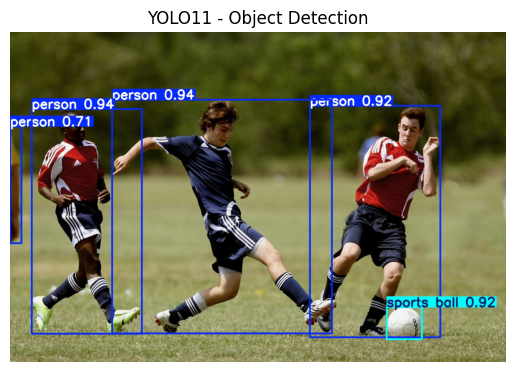

In [60]:
import os

# Load the pre-trained YOLOv11-Medium model
img_path = "football.jpg"
model_type = "yolo11l.pt"

# Ensure the image path is absolute to prevent potential path resolution issues
# absolute_img_path = os.path.abspath(img_path)

prediction(model_type, img_path, task = "Object Detection")


## output:
image 1/1 /content/football.jpg: 448x640 4 persons, 1 sports ball, 36.5ms
Speed: 2.6ms preprocess, 36.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-11

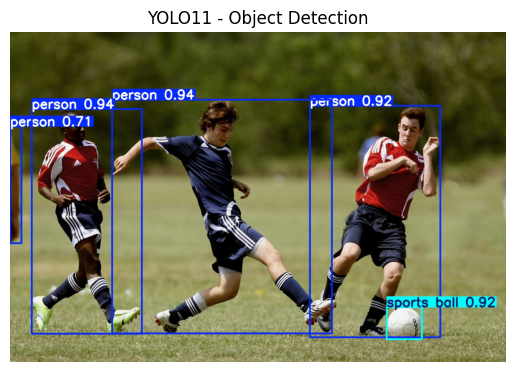

### **Inference 2**


image 1/1 /content/zebra.jpg: 448x640 5 zebras, 36.6ms
Speed: 2.6ms preprocess, 36.6ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-12


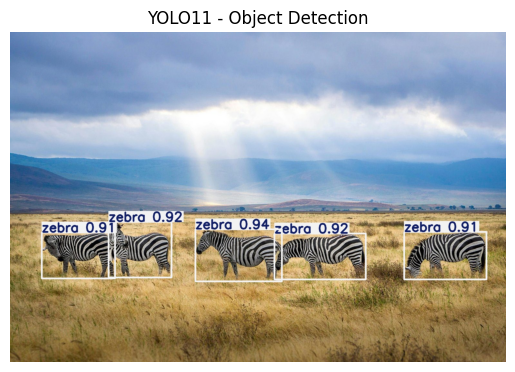

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'p

In [62]:
img_path = "zebra.jpg"
prediction(model_type, img_path, display_result= True, task = "Object Detection")

### output:
image 1/1 /content/zebra.jpg: 448x640 5 zebras, 36.6ms
Speed: 2.6ms preprocess, 36.6ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-12

### image:
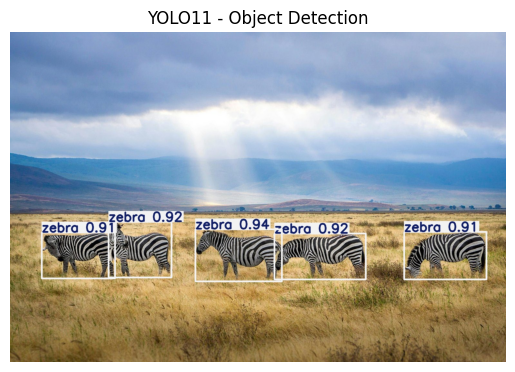

### output(2):
boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microwave', 69: 'oven', 70: 'toaster', 71: 'sink', 72: 'refrigerator', 73: 'book', 74: 'clock', 75: 'vase', 76: 'scissors', 77: 'teddy bear', 78: 'hair drier', 79: 'toothbrush'}
obb: None
orig_img: array([[[179, 126,  93],
        [180, 127,  94],
        [182, 129,  96],
        ...,
        [210, 180, 163],
        [210, 180, 163],
        [213, 181, 168]],

       [[180, 127,  94],
        [181, 128,  95],
        [181, 128,  95],
        ...,
        [210, 180, 163],
        [210, 180, 163],
        [211, 180, 165]],

       [[181, 128,  95],
        [181, 128,  95],
        [181, 128,  95],
        ...,
        [210, 180, 163],
        [210, 180, 163],
        [209, 178, 163]],

       ...,

       [[ 53, 104, 130],
        [ 52, 103, 129],
        [ 50, 101, 127],
        ...,
        [ 68,  98, 133],
        [ 66,  98, 133],
        [ 63,  99, 129]],

       [[ 54, 105, 131],
        [ 53, 104, 130],
        [ 51, 102, 128],
        ...,
        [ 67,  94, 131],
        [ 66,  96, 131],
        [ 62,  98, 128]],

       [[ 53, 104, 130],
        [ 53, 104, 130],
        [ 53, 104, 130],
        ...,
        [ 65,  92, 129],
        [ 64,  94, 129],
        [ 61,  97, 127]]], dtype=uint8)
orig_shape: (1024, 1537)
path: '/content/zebra.jpg'
probs: None
save_dir: '/content/runs/detect/predict-12'
semantic_mask: None
speed: {'preprocess': 2.626276999762922, 'inference': 36.556186000780144, 'postprocess': 1.2663339994105627}]

### **Inference 3**


image 1/1 /content/monitor.jpg: 448x640 1 person, 1 tv, 1 mouse, 1 keyboard, 1 cell phone, 36.5ms
Speed: 2.6ms preprocess, 36.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-13


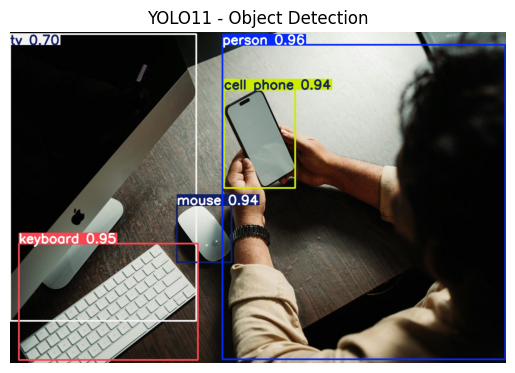

In [63]:
img_path = "monitor.jpg"
prediction(model_type, img_path, task = "Object Detection")

### output:

image 1/1 /content/monitor.jpg: 448x640 1 person, 1 tv, 1 mouse, 1 keyboard, 1 cell phone, 36.5ms
Speed: 2.6ms preprocess, 36.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-13


### image:

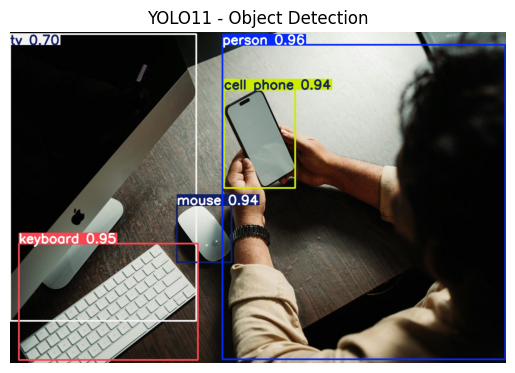

### **Inference 4**


image 1/1 /content/kitchen.jpg: 448x640 2 cups, 1 bowl, 1 dining table, 2 ovens, 1 sink, 1 refrigerator, 36.6ms
Speed: 2.6ms preprocess, 36.6ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-14


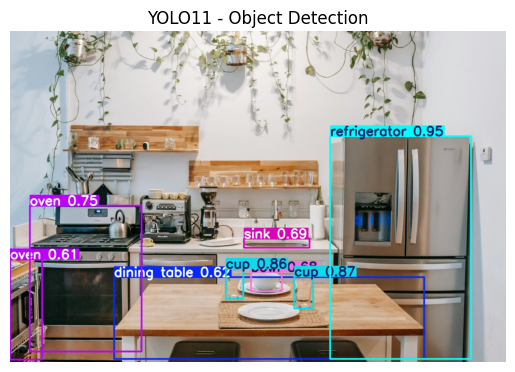

In [64]:
img_path = "kitchen.jpg"
prediction(model_type, img_path, task = "Object Detection")

### output:
image 1/1 /content/kitchen.jpg: 448x640 2 cups, 1 bowl, 1 dining table, 2 ovens, 1 sink, 1 refrigerator, 36.6ms
Speed: 2.6ms preprocess, 36.6ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-14


### prediction:

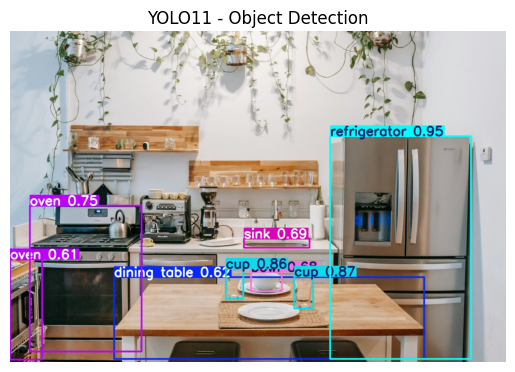



### **Inference 5**


image 1/1 /content/cat-dog.jpg: 640x448 1 cat, 1 dog, 2 potted plants, 99.9ms
Speed: 20.8ms preprocess, 99.9ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict-15


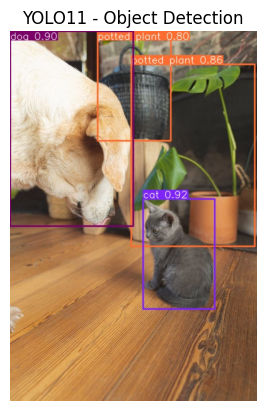

In [65]:
img_path = "cat-dog.jpg"
prediction(model_type, img_path, task = "Object Detection")

# **Pose Estimation**

In [66]:
model_type = "yolo11l-pose.pt"


image 1/1 /content/football.jpg: 448x640 4 persons, 37.8ms
Speed: 2.4ms preprocess, 37.8ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/pose/predict


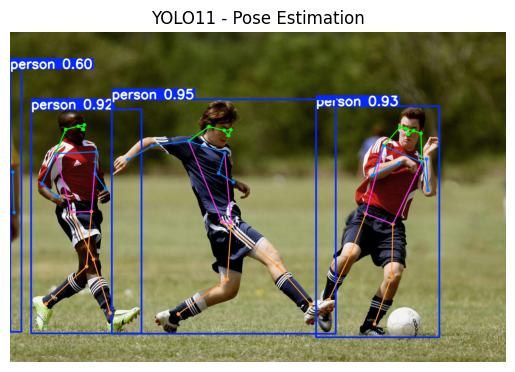

In [67]:
img_path = "football.jpg"

# Predict with the model
prediction(model_type, img_path, task = "Pose Estimation")

### output:
image 1/1 /content/football.jpg: 448x640 4 persons, 37.8ms
Speed: 2.4ms preprocess, 37.8ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/pose/predict


### person + pose of the person (key points of object detection model):

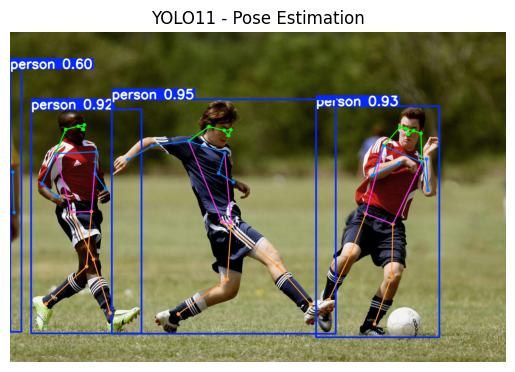

# **Instance Segmentation**

In [68]:
# Load a model
model_type = "yolo11l-seg.pt"


image 1/1 /content/football.jpg: 448x640 4 persons, 1 sports ball, 46.1ms
Speed: 2.5ms preprocess, 46.1ms inference, 41.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/segment/predict


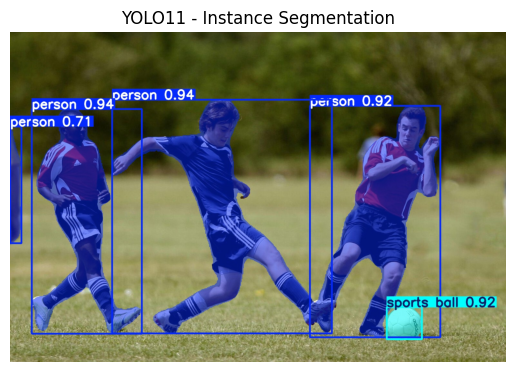

In [69]:
img_path = "football.jpg"

# Predict with the model
prediction(model_type, img_path, task = "Instance Segmentation")

### output:
image 1/1 /content/football.jpg: 448x640 4 persons, 1 sports ball, 46.1ms
Speed: 2.5ms preprocess, 46.1ms inference, 41.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/segment/predict

### Instance Segmentation:

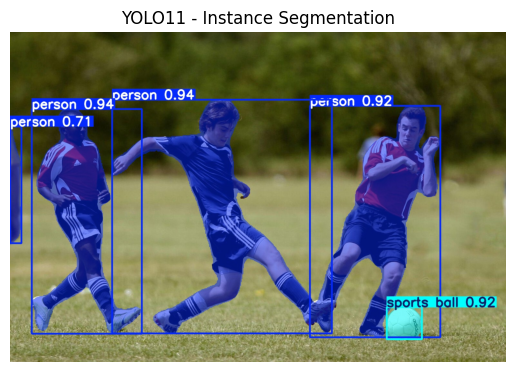

# **Classification**

In [71]:
model_type = "yolo11l-cls.pt"


image 1/1 /content/tiger.jpg: 224x224 tiger 0.70, tiger_cat 0.29, jaguar 0.00, lynx 0.00, cheetah 0.00, 8.1ms
Speed: 42.7ms preprocess, 8.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/classify/predict


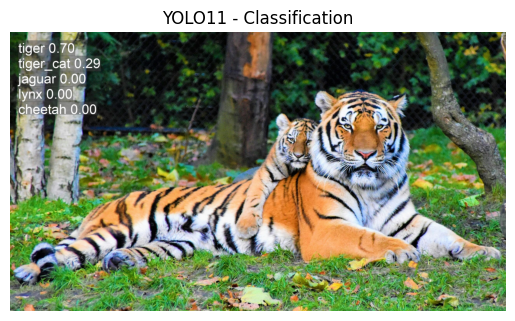

In [72]:
img_path = "tiger.jpg"

# Predict with the model
prediction(model_type, img_path, task = "Classification")

### output:
Downloading https://ultralytics.com/assets/Arial.ttf to '/root/.config/Ultralytics/Arial.ttf': 100% ━━━━━━━━━━━━ 755.1KB 135.6MB/s 0.0s
image 1/1 /content/tiger.jpg: 224x224 tiger 0.70, tiger_cat 0.29, jaguar 0.00, lynx 0.00, cheetah 0.00, 8.1ms
Speed: 42.7ms preprocess, 8.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/classify/predict

### classification:

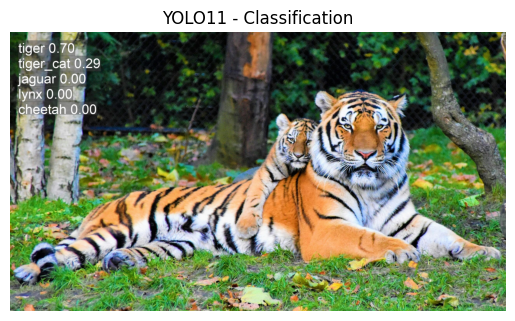


# **Oriented Bounding Box (OBB)**

In [73]:
model_type = "yolo11l-obb.pt"


image 1/1 /content/boat.jpg: 1024x768 1 ship, 82.1ms
Speed: 6.7ms preprocess, 82.1ms inference, 144.7ms postprocess per image at shape (1, 3, 1024, 768)
Results saved to /content/runs/obb/predict


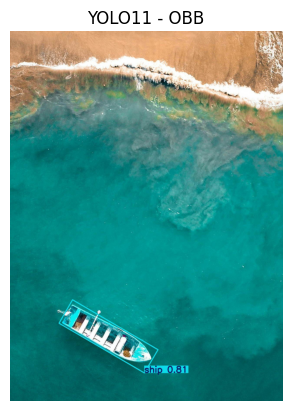

In [74]:
img_path = "boat.jpg"

prediction(model_type, img_path, task = "OBB")

### output:
image 1/1 /content/boat.jpg: 1024x768 1 ship, 82.1ms
Speed: 6.7ms preprocess, 82.1ms inference, 144.7ms postprocess per image at shape (1, 3, 1024, 768)
Results saved to /content/runs/obb/predict

### OBB

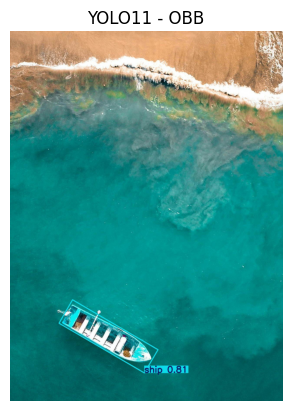

### note: OBB is good, but It's expensive. Bounding box is more used due to having less computation costs.

To know more about architecture details of YOLO models, you may find our [Mastering All YOLO Models](https://learnopencv.com/mastering-all-yolo-models/) summary article to be useful.
